In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from scipy.stats import kstest

# 1 Data load

In [ ]:
df = pd.read_csv("student_career_success_dataset.csv")

# variables
Y = df['Employability_Score']
features = ['CGPA', 'Study_Hours_Per_Week', 'Resume_Score']
X = df[features]
X_const = sm.add_constant(X)

df.head()

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256


# 2 Uji asumsi klasik

In [9]:
model = sm.OLS(Y, X_const).fit()
residuals = model.resid
fitted_values = model.fittedvalues
koefisien = model.params

# persamaan regresi
persamaan = f"Y = {koefisien['const']:.4f}"
for variabel in features:
    nilai_beta = koefisien[variabel]
    
    if nilai_beta >= 0:
        persamaan += f" + {nilai_beta:.4f}({variabel})"
    else:
        persamaan += f" - {abs(nilai_beta):.4f}({variabel})"

print(persamaan)

Y = -130.5193 + 36.1914(CGPA) - 0.0202(Attendance_Percentage) - 0.0075(Study_Hours_Per_Week) + 2.4354(Resume_Score)


## 2.1 Uji normalitas residual

In [10]:
# standardisasi residual
std_residuals = (residuals - residuals.mean()) / residuals.std()


# uji Kolmogorov-Smirnov
ks_stat, ks_pval = kstest(std_residuals, 'norm')

# uji Jarque-Bera
jb_stat, jb_pval, skew, kurtosis = sm.stats.stattools.jarque_bera(residuals)

print("1. Hipotesis")
print("   H0: Residual berdistribusi normal.")
print("   H1: Residual tidak berdistribusi normal.\n")

print("2. Nilai Kritis")
print("   Alpha = 0.05\n")

print("3. Statistik Uji")
print(f"   Kolmogorov-Smirnov: Statistik K-S = {ks_stat:.4f}, P-value = {ks_pval:.5f}")
print(f"   Jarque-Bera: Statistik J-B = {jb_stat:.2f}, P-value = {jb_pval:.5f}\n")

print("4. Keputusan")
if ks_pval < 0.05:
    print(f"   Karena P-value Kolmogorov-Smirnov ({ks_pval:.5f}) < Alpha (0.05), maka H0 ditolak.\n")
else:
    print(f"   Karena P-value Kolmogorov-Smirnov ({ks_pval:.5f}) >= Alpha (0.05), maka H0 gagal ditolak.\n")

print("5. Kesimpulan")
if ks_pval < 0.05:
    print("   Residual dari model ini tidak berdistribusi normal (melanggar asumsi).")
else:
    print("   Residual dari model ini berdistribusi normal (tidak melanggar asumsi).")

1. Hipotesis
   H0: Residual berdistribusi normal.
   H1: Residual tidak berdistribusi normal.

2. Nilai Kritis
   Alpha = 0.05

3. Statistik Uji
   Kolmogorov-Smirnov: Statistik K-S = 0.0099, P-value = 0.00011
   Jarque-Bera: Statistik J-B = 125.78, P-value = 0.00000

4. Keputusan
   Karena P-value Kolmogorov-Smirnov (0.00011) < Alpha (0.05), maka H0 ditolak.

5. Kesimpulan
   Residual dari model ini tidak berdistribusi normal (melanggar asumsi).


1. Uji normalitas
Q-Q Plot: Jika titik mengikuti garis merah, maka residual berdistribusi normal.

2. Uji multikolinearitas
                Variabel       VIF
1                   CGPA  3.840842
2  Attendance_Percentage  2.669028
3   Study_Hours_Per_Week  2.066285
4           Resume_Score  1.117295
Syarat terpenuhi jika nilai VIF < 10.

3. Uji heteroskedsatisitas
Secara visual, pastikan titik-titik menyebar secara acak.

4. Uji linearitas
Hubungan dianggap linear jika sebaran data aktual vs prediksi mengikuti garis diagonal lurus.



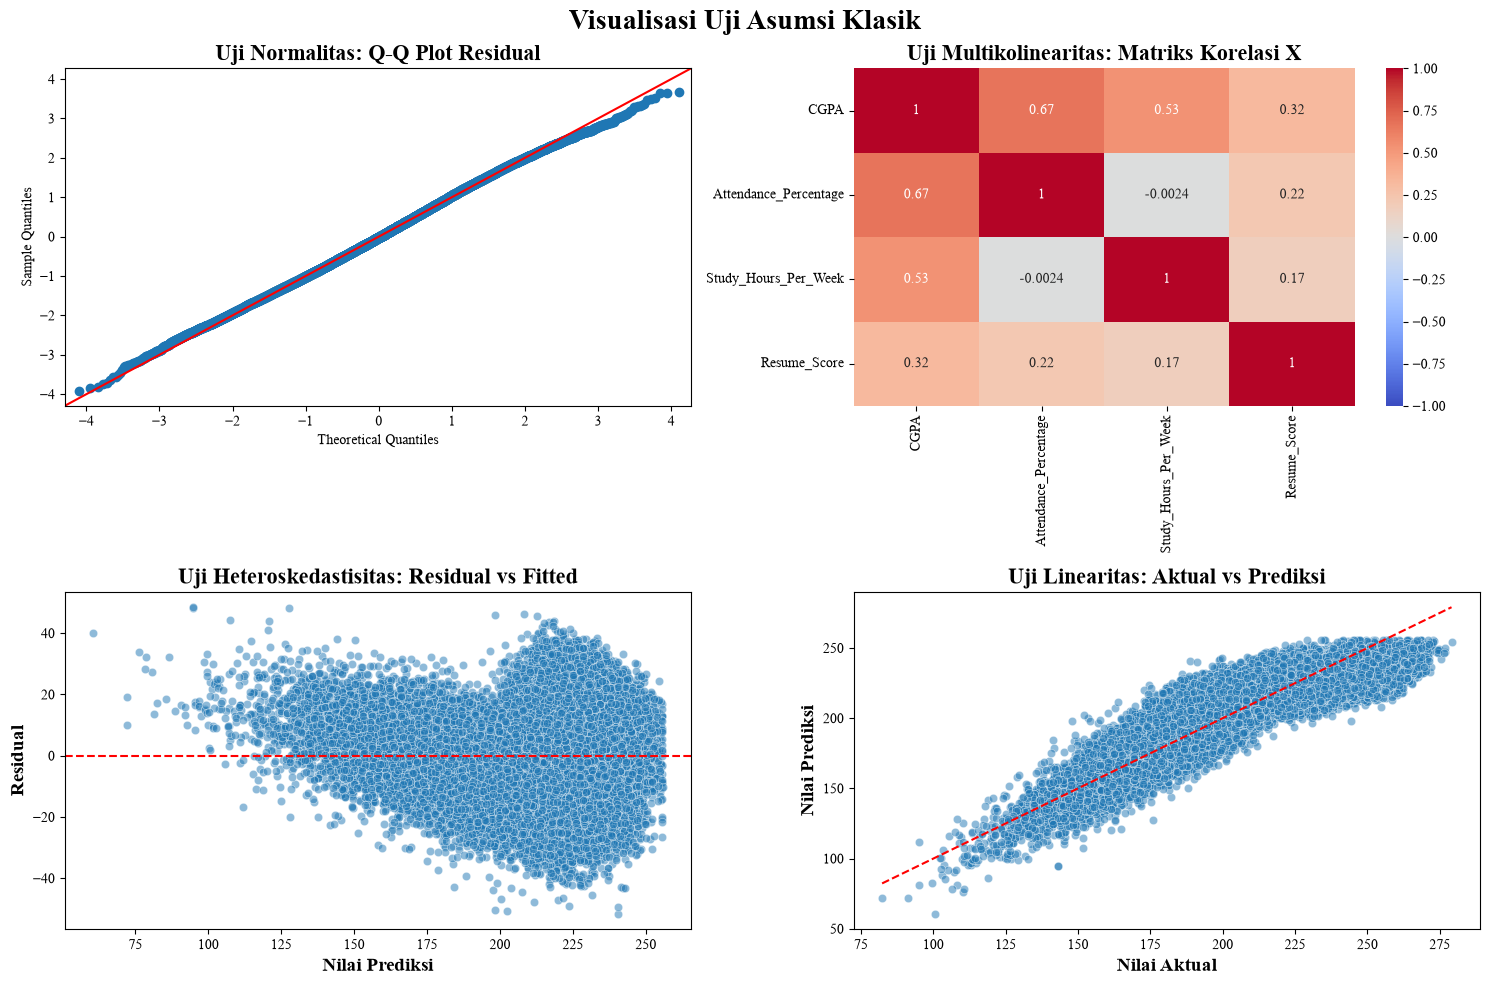

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.rcParams["font.family"] = "Times New Roman"
fig.suptitle('Visualisasi Uji Asumsi Klasik', fontsize=20, fontweight="bold")

# uji normalitas residual: Q-Q plot, Jarque-Bera
sm.qqplot(residuals, line='45', fit=True, ax=axes[0, 0])
axes[0, 0].set_title('Uji Normalitas: Q-Q Plot Residual', fontsize=16, fontweight="bold")
jb_pval = model.pvalues.get('Jarque-Bera', 'N/A (Lihat summary untuk N besar)')
print(f"1. Uji normalitas")
print("Q-Q Plot: Jika titik mengikuti garis merah, maka residual berdistribusi normal.\n")

# 2. Uji multikolinearitas
print(f"2. Uji multikolinearitas")
vif_data = pd.DataFrame()
vif_data["Variabel"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif_data[1:])
print("Syarat terpenuhi jika nilai VIF < 10.\n")
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', ax=axes[0, 1], vmin=-1, vmax=1)
axes[0, 1].set_title('Uji Multikolinearitas: Matriks Korelasi X', fontsize=16, fontweight="bold")

# Uji heteroskedastisitas: scatter plot, breusch-pagan)
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.5, ax=axes[1, 0])
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Nilai Prediksi', fontsize=14, fontweight="bold")
axes[1, 0].set_ylabel('Residual', fontsize=14, fontweight="bold")
axes[1, 0].set_title('Uji Heteroskedastisitas: Residual vs Fitted', fontsize=16, fontweight="bold")

_, pval_bp, _, _ = het_breuschpagan(residuals, X_const)
print(f"3. Uji heteroskedsatisitas")
print("Secara visual, pastikan titik-titik menyebar secara acak.\n")

# 4. Uji linearitas: scatter plot Aktual vs Prediksi
sns.scatterplot(x=Y, y=fitted_values, alpha=0.5, ax=axes[1, 1])
axes[1, 1].plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='red', linestyle='--')
axes[1, 1].set_xlabel('Nilai Aktual', fontsize=14, fontweight="bold")
axes[1, 1].set_ylabel('Nilai Prediksi', fontsize=14, fontweight="bold")
axes[1, 1].set_title('Uji Linearitas: Aktual vs Prediksi', fontsize=16, fontweight="bold")

print(f"4. Uji linearitas")
print("Hubungan dianggap linear jika sebaran data aktual vs prediksi mengikuti garis diagonal lurus.\n")

plt.tight_layout()
plt.show()

# 3 Regresi

In [12]:
# 1. konversi ke array Numpy
Y_arr = Y.values
n_rows = len(Y_arr)

# bentuk matriks X
X_mat_list = [np.ones(n_rows)]
for col in features:
    X_mat_list.append(df[col].values)
    
X_arr = np.column_stack(X_mat_list)

# 2. bentuk normal equation: (X^T * X) * Beta = (X^T * Y) -> A * Beta = b
A = X_arr.T @ X_arr
b = X_arr.T @ Y_arr

print("Sistem persamaan linear")
print(f"Matriks A (X^T X) ordo {A.shape}:\n", np.round(A, 2))
print(f"\nVektor b (X^T Y) ordo {b.shape}:\n", np.round(b, 2))

# 3. fungsi dekomposisi LU (metode Doolittle)
def lu_decomposition(mat):
    n = len(mat)
    L = np.zeros((n, n))
    U = np.zeros((n, n))
    
    for i in range(n):
        # matriks U (upper)
        for k in range(i, n):
            sum_val = sum([L[i][j] * U[j][k] for j in range(i)])
            U[i][k] = mat[i][k] - sum_val
            
        # matriks L (lower)
        for k in range(i, n):
            if i == k:
                L[i][i] = 1 # Diagonal utama L wajib 1
            else:
                sum_val = sum([L[k][j] * U[j][i] for j in range(i)])
                L[k][i] = (mat[k][i] - sum_val) / U[i][i]
    return L, U

L_mat, U_mat = lu_decomposition(A)

# 4. fungsi substitusi
def forward_substitution(L, b):
    n = len(L)
    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - sum(L[i][j] * y[j] for j in range(i))
    return y

def backward_substitution(U, y):
    n = len(U)
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - sum(U[i][j] * x[j] for j in range(i+1, n))) / U[i][i]
    return x

# 5. cari parameter (Beta)
y_vec = forward_substitution(L_mat, b)
beta_manual = backward_substitution(U_mat, y_vec)

# 6. hasil
print("\nParameter regresi (Lu-Gauss)")
print(f"Beta_0 (Intercept)\t\t: {beta_manual[0]:.6f}")
for i, feature in enumerate(features):
    print(f"Beta_{i+1} ({feature})\t: {beta_manual[i+1]:.6f}")

beta_numpy = np.linalg.solve(A, b)
error_max = np.max(np.abs(beta_manual - beta_numpy))
print(f"\nValidasi error (selisih dengan fungsi bawaan komputasi): {error_max:.15e}")

Sistem persamaan linear
Matriks A (X^T X) ordo (5, 5):
 [[5.00000000e+04 1.55302140e+05 4.07048200e+06 1.07640800e+06
  4.80228700e+06]
 [1.55302140e+05 4.86590190e+05 1.27372111e+07 3.39735460e+06
  1.49505743e+07]
 [4.07048200e+06 1.27372111e+07 3.36090118e+08 8.76219440e+07
  3.91750949e+08]
 [1.07640800e+06 3.39735460e+06 8.76219440e+07 2.56054340e+07
  1.03808954e+08]
 [4.80228700e+06 1.49505743e+07 3.91750949e+08 1.03808954e+08
  4.63926747e+08]]

Vektor b (X^T Y) ordo (5,):
 [1.06995697e+07 3.34675003e+07 8.76303793e+08 2.33311774e+08
 1.03542124e+09]

Parameter regresi (Lu-Gauss)
Beta_0 (Intercept)		: -130.519345
Beta_1 (CGPA)	: 36.191356
Beta_2 (Attendance_Percentage)	: -0.020224
Beta_3 (Study_Hours_Per_Week)	: -0.007471
Beta_4 (Resume_Score)	: 2.435362

Validasi error (selisih dengan fungsi bawaan komputasi): 9.237055564881302e-12
